In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

In [2]:
from MDP.USTFutures.USTFutureOptionMDP import USTFutureOptionMDP
from MDP.USTFutures.USTFuturesMDP import USTFuturesMDP

In [3]:
ustf_mdp = USTFuturesMDP(source="BARCHART_USTF-RL")
ustfo_bc_mdp = USTFutureOptionMDP(source="BARCHART_USTFO-QL")
ustfo_qs_mdp = USTFutureOptionMDP(source="USTFO_DUAL-QL")

In [4]:
as_of = datetime.date(2026, 3, 23)

out = ustfo_bc_mdp.get_pricer({
    "endpoint": "option_snapshot",
    "symbols": ["TYM26|ATMS"],  
    "timestamp": as_of,
    "show_tqdm": True,
    "use_ql_calculator": True,
	# "force_refresh": True
})

pr = next(iter(out.values()))[0]
print("resolved_symbol:", pr.symbol())
print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())

resolved_symbol: ZNM26|1110S
price: 2.265625 iv_normal_bps: 106.87836873162848
delta: -0.021689938880911086 gamma: 0.27756197390143866 vega: 0.32139617927332387 theta: -6.8015133316148795


In [5]:
as_of = datetime.date(2025, 4, 3)

out = ustfo_qs_mdp.get_pricer({
    "endpoint": "option_snapshot",
    "symbols": ["TY_30|ATMS"],  
    "timestamp": as_of,
    "show_tqdm": True,
    "use_ql_calculator": True,
	# "force_refresh": True
})
out
pr = next(iter(out.values()))[0]
print("resolved_symbol:", pr.symbol())
print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())

resolved_symbol: TY_30|ATMS
price: 1.775116007519459 iv_normal_bps: 117.38934585896506
delta: 0.050135834827210846 gamma: 0.3560484828197446 vega: 0.22746676907760857 theta: -10.677580427258153


In [10]:
with ustfo_qs_mdp:
	# smiles = ustfo_qs_mdp.fetch_bulk_sabr_smile(
	# 	{
	# 		"globex_symbols": ["TU_30", "FV_30", "TY_30", "TN_30", "US_30", "UL_30"],
	# 		"timestamps": [
    #             datetime.date(2026, 2, 2),
    #         #     datetime.date(2026, 3, 3),
    #         #     datetime.date(2026, 3, 4),
    #         #     datetime.date(2026, 3, 5),
    #         #     datetime.date(2026, 3, 6),
    #         ],
	#         "show_tqdm": True,
	# 		# "force_refresh": True,
	# 	}
	# )
	# smiles_2 = ustfo_qs_mdp.fetch_bulk_sabr_smile(
	# 	{
	# 		"globex_symbols": ["TN_30", "US_30", "UL_30"],
	# 		"timestamps": [
    #             datetime.date(2026, 3, 5),
    #             datetime.date(2026, 3, 6),
    #         ],
	#         "show_tqdm": True,
	# 		# "force_refresh": True,
	# 	}
	# )

	smile = ustfo_qs_mdp.fetch_sabr_smile(
		{
			"globex_symbol": "TY_30",
			"as_of": datetime.date(2026, 3, 23),
			# "calibration_method": "de-gn",
	        "show_tqdm": True,
		}
	)

# smiles = smiles_1 | smiles_2
# smiles
smile

FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 1/1 [00:00<00:00,  3.29it/s]


USTFutureOptionSABRSmile(source='USTFO_DUAL-QL', globex_symbol='TY_30', underlying_contract='ZNM26', quote_timestamp=datetime.datetime(2026, 3, 23, 0, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), fv01=0.06590715411168871, params=USTFutureOptionSABRParams(alpha=0.6417947683770198, beta=0.5, rho=-0.26965908312919906, nu=2.6466782383048573, forward_price=110.921875, forward_futures_ytm=4.151159836717647, time_to_expiry=0.0821917808219178, expiry_date=datetime.date(2026, 4, 22), as_of=datetime.date(2026, 3, 23), calibration_rmse=0.09445519350735952), points=(USTFutureOptionSmilePoint(label='TY_30 5D Put', right='P', delta_abs=5.0, strike_price=105.88555368544907, strike_futures_ytm=4.964613330557069, iv_normal_price=10.680017840078635, iv_normal_bps=162.0464118656964), USTFutureOptionSmilePoint(label='TY_30 10D Put', right='P', delta_abs=10.0, strike_price=107.43116581709377, strike_futures_ytm=4.710266725745969, iv_normal_price=9.500870266042535, iv_normal_bps=144.15

USTFutureOptionSABRParams(alpha=0.6417947683770198, beta=0.5, rho=-0.26965908312919906, nu=2.6466782383048573, forward_price=110.921875, forward_futures_ytm=4.151159836717647, time_to_expiry=0.0821917808219178, expiry_date=datetime.date(2026, 4, 22), as_of=datetime.date(2026, 3, 23), calibration_rmse=0.09445519350735952)
forward price: 110.921875
forward futures ytm: 4.151159836717647
fv01: 0.06590715411168871


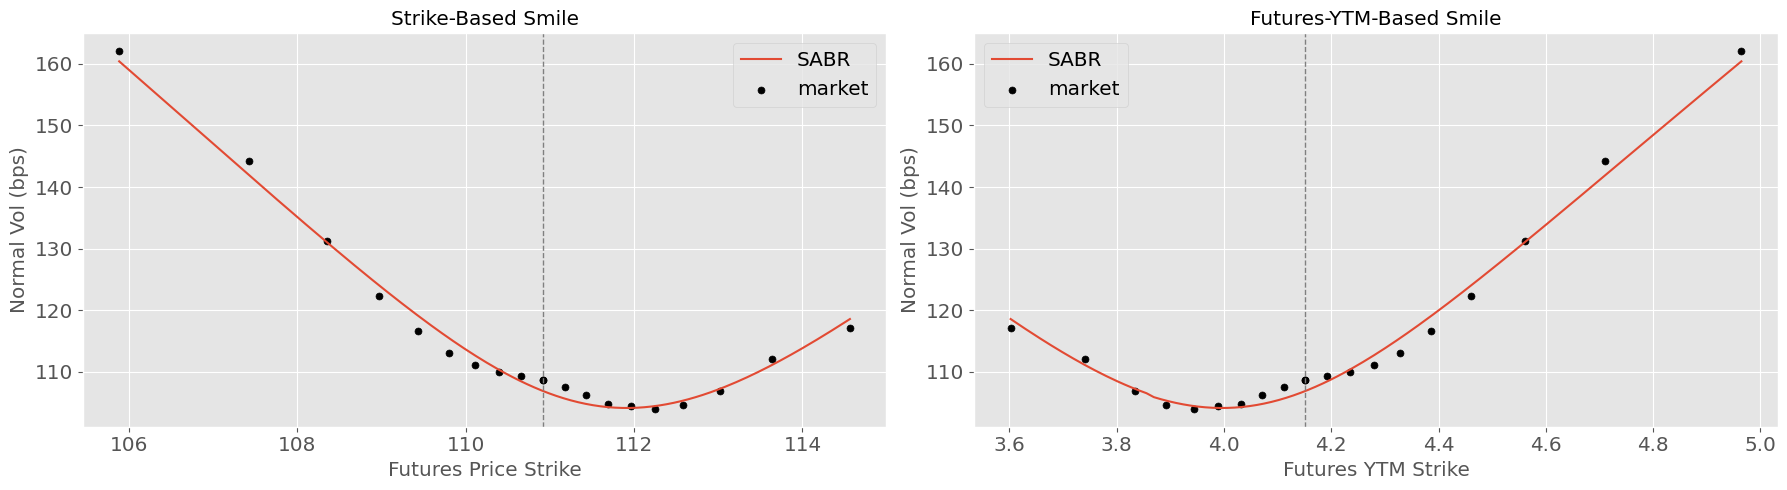

In [11]:
# smile = smiles["FV_30"][datetime.date(2026, 3, 6)]
print(smile.params)
print("forward price:", smile.params.forward_price)
print("forward futures ytm:", smile.params.forward_futures_ytm)
print("fv01:", smile.fv01)

# strike-based grid
price_strikes = np.linspace(
    min(p.strike_price for p in smile.points),
    max(p.strike_price for p in smile.points),
    200,
)
price_vols_bps = smile.normal_vol(price_strikes, strike_space="price", vol_units="bps")

# YTM-based grid
ytm_strikes = np.linspace(
    min(p.strike_futures_ytm for p in smile.points),
    max(p.strike_futures_ytm for p in smile.points),
    200,
)
ytm_vols_bps = smile.normal_vol(ytm_strikes, strike_space="futures_ytm", vol_units="bps")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(price_strikes, price_vols_bps, label="SABR")
axes[0].scatter([p.strike_price for p in smile.points], [p.iv_normal_bps for p in smile.points], s=25, c="black", label="market")
axes[0].axvline(smile.params.forward_price, ls="--", lw=1, c="gray")
axes[0].set_title("Strike-Based Smile")
axes[0].set_xlabel("Futures Price Strike")
axes[0].set_ylabel("Normal Vol (bps)")
axes[0].legend()

axes[1].plot(ytm_strikes, ytm_vols_bps, label="SABR")
axes[1].scatter([p.strike_futures_ytm for p in smile.points], [p.iv_normal_bps for p in smile.points], s=25, c="black", label="market")
axes[1].axvline(smile.params.forward_futures_ytm, ls="--", lw=1, c="gray")
axes[1].set_title("Futures-YTM-Based Smile")
axes[1].set_xlabel("Futures YTM Strike")
axes[1].set_ylabel("Normal Vol (bps)")
axes[1].legend()

plt.tight_layout()
plt.show()